Notebook para fazer visualizações e comparações entre distribuições CPRI e Poisson.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, errno
import sys

#Settings
BASE_DIR = 'test_poissonPG_IPACT_pred_2'
NUMBER_OF_OLTs = 1
NUMBER_OF_ONUs = 3
DISTANCE = 20 #Distance in kilometers
TRAFFIC = "poisson"
DBA_ALG = "ipact_pred"


IPACT = {}
#load % values which represents each exponent
#loads = [25,31,37,43,50,56,62,68,75,81,87,93]
loads = [10, 20, 30, 40, 50, 60, 70, 80]
#pkt arrival distribution exponents
#exponents = [1160, 1450, 1740, 2030, 2320, 2610, 2900, 3190, 3480, 3770, 4060, 4350]
exponents = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
# To do a complete test: uncomment the line below
#seeds = [20,30,40,50,60,70,80,90,100,110] #random seeds
# To do a FAST test: uncomment the line below
seeds = [20, 30, 40]
parameters = [{'w':10, 'p':3}, {'w':12, 'p':2}, {'w':15, 'p':3}, {'w':5, 'p':2}]

PKT_SIZES = ['768000']

for param in parameters:
    IPACT['{}-{}'.format(param['w'],param['p'])] = {}

Leitura dos dados gerados em tráfego Poisson e criação de dataframe (Alterado para lidar com múltiplas seeds e combinações de 'w' e 'p').

In [8]:
for params in parameters:    
    for exp in exponents:
        for payload_size in PKT_SIZES:
            ipact = []
            for seed in seeds:
                df_tmp = pd.read_csv("{}/csv/delay/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-delay.csv".format(BASE_DIR, DBA_ALG, DISTANCE,
                                                                                                NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                TRAFFIC, exp, payload_size, params['w'], params['p'], seed))
                ipact.append(df_tmp['delay'].mean()*1000)
            
            media = np.mean(ipact)
            std = np.std(ipact)
            IPACT['{}-{}'.format(params['w'], params['p'])][exp] = [media, std]

ipact_df = pd.DataFrame(IPACT)

In [ ]:
df_tmp = pd.read_csv('{}/csv/delay/ipact-dist20-3ONUs-1OLTs-cbr-exp0-pkt768000-s20-delay.csv'.format(BASE_DIR))
aux = df_tmp['delay']*1000
aux_2 = [np.mean(aux), np.std(aux)]
df_tmp = pd.DataFrame(aux_2)

In [ ]:
df_tmp

Abertura de figura e edição de título.

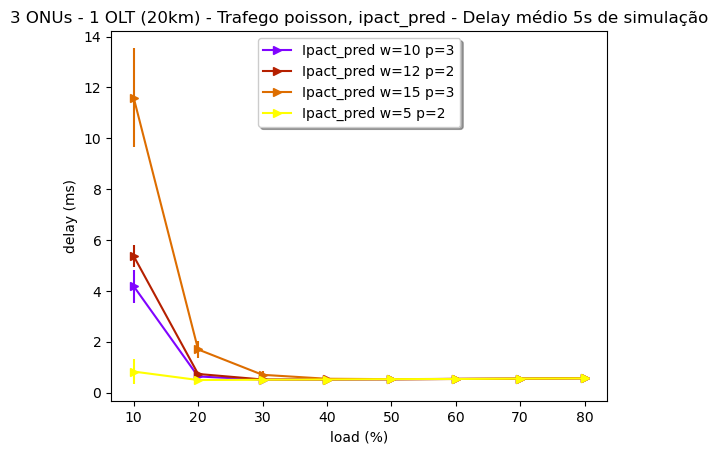

In [ ]:
plt.figure()
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - Delay médio 5s de simulação".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("delay (ms)")
cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(0.25, 1, 4)]
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

for j, param in enumerate(parameters):
    aux_label = 'Ipact_pred w={} p={}'.format(param['w'], param['p'])
    array_aux = np.array([ i for i in ipact_df['{}-{}'.format(param['w'], param['p'])].iloc[:] ])
    #print(array_aux)
    plt.errorbar(loads, array_aux[:,0], array_aux[:,1], color=colors[j], linestyle='None')
    plt.plot(loads, array_aux[:,0], '->', color=colors[j], label=aux_label)
    print(array_aux[:,0])

#plt.axhline(y=df_tmp[0][0], color='r', linestyle='-', label='CPRI-1')

plt.legend(loc='upper center', shadow=True)
plt.show()

Geração de histogramas do tempo de geração de pkts

In [ ]:

for exp in exponents:
    for seed in seeds:
        plt.clf()

        df_tmp = pd.read_csv("{}/csv/pkt/ipact_pred-dist20-3ONUs-1OLTs-poisson-exp{}-pkt768000-s{}-pkt.csv".format(BASE_DIR, exp, seed))
        plt.hist(df_tmp['timestamp'])
        plt.savefig('Hist-exp{}-s{}.png'.format(exp, seed))
plt.show()

Observação de Mean Squared Error.

In [ ]:
for param in parameters :
    for exp in exponents:
        for payload_size in PKT_SIZES:
            ipact_pred_msestart = []
            ipact_pred_mseend = []
            for seed in seeds:
                df_tmp = pd.read_csv("{}/csv/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-mse.csv".format(
                        BASE_DIR, DBA_ALG, 20, NUMBER_OF_ONUs, NUMBER_OF_OLTs, TRAFFIC, exp, payload_size, param['w'], param['p'], seed)
                )
                
                ipact_pred_msestart.append(df_tmp['mse_start'])
                ipact_pred_mseend.append(df_tmp['mse_end'])
                
                media = np.mean(ipact_pred_msestart)
                media2 = np.mean(ipact_pred_mseend)
                #std = np.std(ipact_pred_msestart)

            IPACT['{}-{}'.format(param['w'],param['p'])][exp] = [media, media2]

ipact_df = pd.DataFrame(IPACT)

In [ ]:
plt.clf()
#creating figure
plt.figure()

title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - MSE end 5s de simulação".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG)
plt.title(title)
plt.xlabel("Occupation (%)")
plt.ylabel("Mean Squared error")

number = 4
cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(0.25, 1, number)]

br = []
for j, param in enumerate(parameters):
    aux_label = 'Ipact_pred w={} p={}'.format(param['w'], param['p'])
    array_aux = np.array([ i for i in ipact_df['{}-{}'.format(param['w'], param['p'])].iloc[:] ])
    if len(br) != 0:
        br = [x+0.15 for x in br]
    else:
        br = np.arange(len(array_aux[:,1]))
    plt.bar(br, array_aux[:,1], color=colors[j], edgecolor="grey", width=0.15, label=aux_label)

plt.xticks([r+0.30 for r in np.arange(len(array_aux[:,1]))], exponents)

plt.legend(loc='upper center', shadow=True)
plt.show()
